In [2]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, datetime as dt, numpy as np, glob, os
%pip install statsmodels
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as sm
pd.set_option('display.max_columns', None)

DRIVE_URL = "https://drive.google.com/uc?export=download&id=1F06NYKBF8loCTPEaPT_qIhcQy2T5iM6H"
DATA_PATH = "data.csv"

# Preferred: local multi-file raw data. Fallback: single downloaded CSV.
all_files = sorted(glob.glob("csv_files/get_it_done_requests_closed_20*_datasd.csv"))

if all_files:
    print(f"Loading {len(all_files)} local annual CSV files from csv_files/...")
    df_list = []
    for file in all_files:
        year = file.split('_')[-2]
        df = pd.read_csv(file)
        if 'year' not in df.columns:
            df['year'] = year
        df_list.append(df)
        print(f"Loaded {year}: {len(df)} rows")
    all_data = pd.concat(df_list, ignore_index=True)
else:
    if not os.path.exists(DATA_PATH):
        print("No local annual CSV files found. Attempting Google Drive download...")
        try:
            import gdown
            gdown.download(DRIVE_URL, DATA_PATH, quiet=False)
        except Exception as e:
            raise RuntimeError(
                "Could not load local CSVs and automatic download failed. "
                "Install gdown (`pip install gdown`) or place data.csv in project root."
            ) from e

    all_data = pd.read_csv(DATA_PATH, low_memory=False)
    if 'year' not in all_data.columns and 'date_requested' in all_data.columns:
        all_data['date_requested'] = pd.to_datetime(all_data['date_requested'], errors='coerce')
        all_data['year'] = all_data['date_requested'].dt.year
    print(f"Loaded single-file dataset: {len(all_data):,} rows")

master = all_data[all_data["status"] != "Referred"].drop(columns=["referred"])
# Clean neighborhood names
master["comm_plan_name"] = master["comm_plan_name"].str.title()

# calculate counts and merge
service_name_count = (master.value_counts(subset=["service_name"])
                      .rename_axis("service_name")
                      .reset_index(name="case_type_count"))
neighborhood_count = (master.value_counts("comm_plan_name")).reset_index(name = "neighborhood_count")
district_count = (master.value_counts("council_district")).reset_index(name = "district_count")

# Merge counts into master
master = master.merge(service_name_count, on="service_name", how="left")
master = master.merge(neighborhood_count, on="comm_plan_name", how="left")
master = master.merge(district_count, on = "council_district", how = "left")




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_80368/1793848924.py:12: DtypeWarning: Columns (7,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2016: 33631 rows
Loaded 2017: 139500 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_80368/1793848924.py:12: DtypeWarning: Columns (2,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2018: 169603 rows


...

Loaded 2019: 302699 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_80368/1793848924.py:12: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2020: 280071 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_80368/1793848924.py:12: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2021: 359879 rows
Loaded 2022: 349241 rows
Loaded 2023: 432431 rows
Loaded 2024: 429933 rows
Loaded 2025: 378618 rows


## Data Preparation

This notebook focuses on district and neighborhood equity analysis.

### Preparation Steps
- Apply cleaning and standardization from the citywide pipeline
- Validate district/neighborhood labels and request timing fields
- Build grouped statistics for district and community-plan comparisons


In [3]:
master = all_data[all_data["status"] != "Referred"].drop(columns=["referred"])
# Clean neighborhood names
master["comm_plan_name"] = master["comm_plan_name"].str.title()
def clean_case_type(case):
    if not isinstance(case,str):
        return case
    
    if "graffiti" in case.lower():
        return "Graffiti"
    return case

#Drop rows where service_name == "Other"(vague)
before_rows = len(master)
master = master[master["service_name"] != "Other"]
print(f"✓ Dropped 'Other' service type: {before_rows - len(master):,} rows")
#Remove invalid case_age_days (negative values)
before_rows = len(master)
master = master[master["case_age_days"] >= 0]
print(f"✓ Dropped negative response times: {before_rows - len(master):,} rows")
#Remove duplicates
before_rows = len(master)
master = master[~master['service_request_id'].duplicated()]
print(f"✓ Dropped duplicate IDs: {before_rows - len(master):,} rows")

#Clean service_name values
master["service_name"] = master["service_name"].apply(clean_case_type)

#Drop rows with NA in service_name
before_rows = len(master)
master = master.dropna(subset=["service_name"])
after_rows = len(master)

print(
    
    f"Dropped {before_rows - after_rows} rows due to NA values"
)
#Handling Missing Features for Modeling


# Fill missing comm_plan_name with 'Unknown'
missing_neighborhood = master['comm_plan_name'].isna().sum()
master['comm_plan_name'] = master['comm_plan_name'].fillna('Unknown')
print(f"✓ Filled {missing_neighborhood:,} missing neighborhoods with 'Unknown'")

# Fill missing case_origin with 'Unknown'
missing_origin = master['case_origin'].isna().sum()
master['case_origin'] = master['case_origin'].fillna('Unknown')
print(f"✓ Filled {missing_origin:,} missing case_origins with 'Unknown'")



✓ Dropped 'Other' service type: 26,693 rows
✓ Dropped negative response times: 670 rows
✓ Dropped duplicate IDs: 17 rows
Dropped 692 rows due to NA values
✓ Filled 32,519 missing neighborhoods with 'Unknown'
✓ Filled 479 missing case_origins with 'Unknown'


## Median Response Time by Council District

This section summarizes `case_age_days` by district using robust central tendency (median).

### Goal
Identify district-level differences in service response speed and establish where deeper composition analysis is needed.


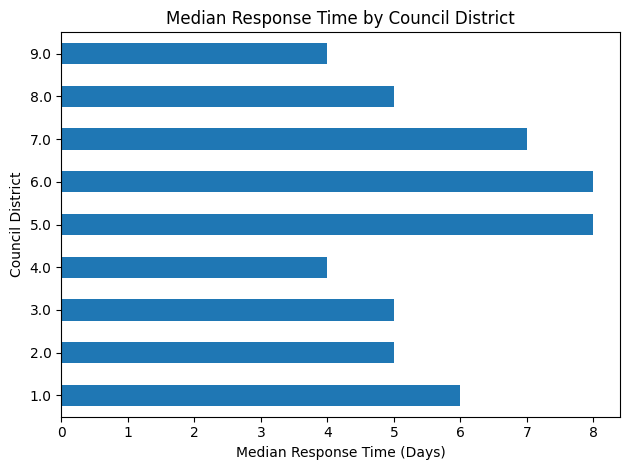

                       mean  median   count
council_district                           
1.0               51.921976     6.0  203130
2.0               42.924490     5.0  373621
3.0               45.802043     5.0  569366
4.0               35.979223     4.0  221493
5.0               63.804487     8.0   95963
6.0               47.072316     8.0  141878
7.0               48.919946     7.0  169149
8.0               37.891149     5.0  249349
9.0               38.377792     4.0  446968


In [4]:
district_case_average["median"].plot(kind = "barh")
plt.xlabel('Median Response Time (Days)')
plt.ylabel('Council District')
plt.title('Median Response Time by Council District')
plt.tight_layout()
plt.show()
print(district_case_average)



## Median Response Time by Neighborhood

This section extends district-level analysis to community-plan geography.

### Goal
Detect finer-grained geographic variation that can be masked at the district level.


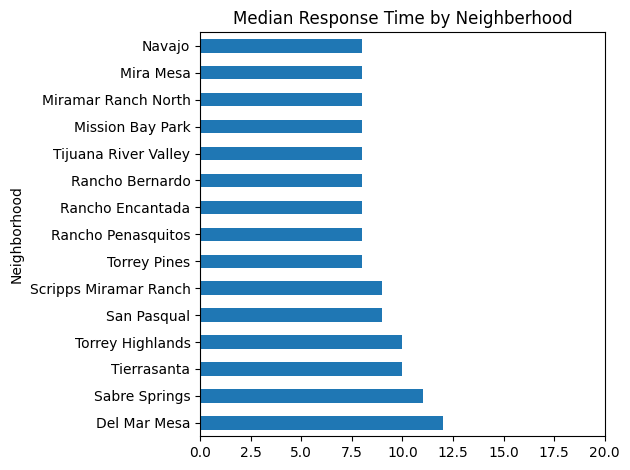

                                   mean  median   count
comm_plan_name                                         
Balboa Park                   54.008338     7.0   23388
Barrio Logan                  40.544240     3.0   21112
Black Mountain Ranch          49.942852     7.0    5197
Carmel Mountain Ranch         59.727645     7.0    9025
Carmel Valley                 58.543052     7.0   20510
Clairemont Mesa               44.367649     5.0  134974
College Area                  45.697739     6.0   48607
Del Mar Mesa                  96.096189    12.0     551
Downtown                      42.033188     5.0  208476
East Elliott                  50.072193     6.0     374
Encanto Neighborhoods         33.858015     3.0   89566
Fairbanks Ranch Country Club  66.710438     8.0     297
Greater Golden Hill           49.264709     6.0   41914
Kearny Mesa                   47.030471     7.0   31112
La Jolla                      57.891260     7.0   59279


In [5]:
top15 = (
    neighberhood_case_average[neighberhood_case_average["count"]>500]
    ["median"]
    .sort_values(ascending = False)
    .head(15)
    .plot(kind = "barh")
)
plt.ylabel('Neighborhood')
plt.title('Median Response Time by Neighberhood')
plt.xlim(0, 20)
plt.tight_layout()
plt.show()
print(neighberhood_case_average.head(15))

## Districts 5 and 6 vs Other Districts: Time Trend Analysis

This section evaluates whether the response-time gap persists over time and whether it appears structural versus transient.

- As we can see, response times started off really high in the beginning of the service(around 2017)
- There was a large jump in 2020-2021, due to covid-19, shutting down the world, and making it way harder to fix infrastructure
- However, ever since then, we can see that all the districts median response times have went down, with districts 5-6 still being the highest


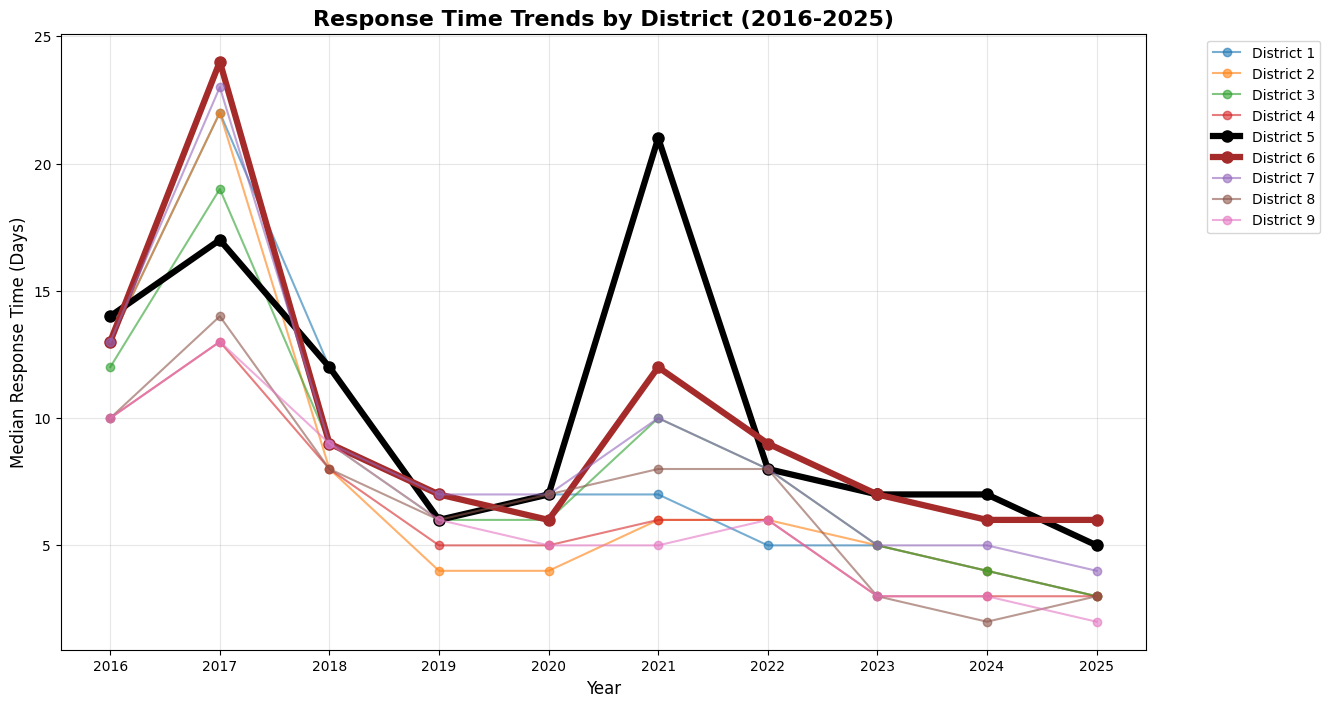

In [6]:
# Year-by-year district comparison
district_trends = (master.groupby(['year', 'council_district'])['case_age_days']
                   .median()
                   .reset_index())

# Plot trends
plt.figure(figsize=(14, 8))
for district in range(1, 10):
    data = district_trends[district_trends['council_district'] == district]
    
    if district in [5, 6]:
        plt.plot(data['year'], data['case_age_days'], 
                marker='o', linewidth=4.5, markersize=8, 
                label=f'District {district}',
                color='black' if district == 5 else 'brown')
    else:
        plt.plot(data['year'], data['case_age_days'], 
                marker='o', linewidth=1.5, alpha=0.6, 
                label=f'District {district}')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Median Response Time (Days)', fontsize=12)
plt.title('Response Time Trends by District (2016-2025)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
#plt.tight_layout()
plt.savefig('district_trends_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Significance Checks

This section validates whether observed district-group differences are large enough to warrant follow-up analysis beyond descriptive charts.


In [7]:
slow_districts = master[master["council_district"].isin([5,6])]
fast_districts = master[master["council_district"].isin([1, 2, 3, 4, 7, 8, 9])]
print("=== MULTI-YEAR COMPARISON (2016-2025) ===")
print(f"Districts 5 & 6:")
print(f"  Median: {slow_districts['case_age_days'].median():.1f} days")
print(f"  Mean: {slow_districts['case_age_days'].mean():.1f} days")
print(f"  Requests: {len(slow_districts):,}")

print(f"\nOther Districts:")
print(f"  Median: {fast_districts['case_age_days'].median():.1f} days")
print(f"  Mean: {fast_districts['case_age_days'].mean():.1f} days")
print(f"  Requests: {len(fast_districts):,}")

ratio = slow_districts['case_age_days'].median() / fast_districts['case_age_days'].median()
print(f"\n⚠️ Districts 5 & 6 wait {ratio:.2f}x longer")
print(f"Districts 5 & 6 account for {round(len(slow_districts)/len(fast_districts),2)*100}% of the requests")
print(f"Normal would be around 22% of the requests")

=== MULTI-YEAR COMPARISON (2016-2025) ===
Districts 5 & 6:
  Median: 8.0 days
  Mean: 54.2 days
  Requests: 235,447

Other Districts:
  Median: 5.0 days
  Mean: 42.9 days
  Requests: 2,208,299

⚠️ Districts 5 & 6 wait 1.60x longer
Districts 5 & 6 account for 11.0% of the requests
Normal would be around 22% of the requests


## Response-Time Distribution Comparison

Histogram overlays compare the full response-time distribution for Districts 5 and 6 versus other districts.

### Insight Focus
Distribution shape helps determine whether differences are concentrated in tails or spread across the full range.


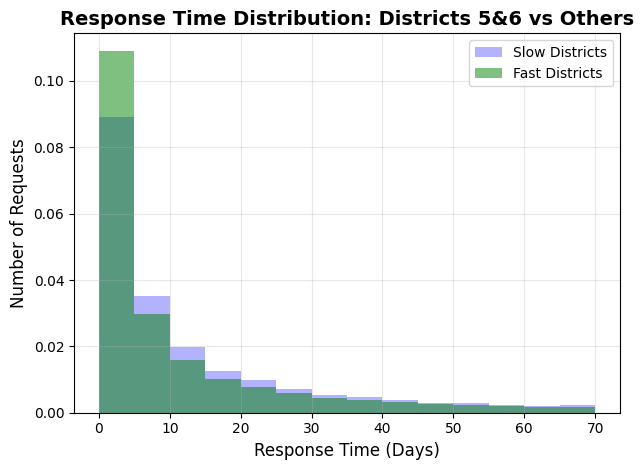

In [8]:
plt.Figure(figsize=(12,6))
plt.hist(slow_districts["case_age_days"], bins = np.arange(0, 75, 5), density=True, alpha = 0.3, color="blue", label = "Slow Districts");
plt.hist(fast_districts["case_age_days"], bins = np.arange(0, 75, 5), density=True, alpha = 0.5, color = "green", label = "Fast Districts");
plt.xlabel('Response Time (Days)', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.title('Response Time Distribution: Districts 5&6 vs Others', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Infrastructure Composition Analysis

This section tests whether district wait-time disparities are driven by differences in request mix.

### Key Documented Pattern
Districts 5 and 6 show substantially higher infrastructure-request share in this analysis, which explains a meaningful portion of aggregate delay differences.


In [9]:
case_type = "service_name"

infrastructure_types = [
    'Pothole',
    'Street Light Maintenance',
    'Traffic Signal Issue',
    'Traffic Signal Timing',
    'Traffic Sign Maintenance',
    'Sidewalk Repair Issue',
    'Pavement Maintenance',
    'Street Repair',
    'Curb Repair'
]

fast_infra_count = len(
    fast_districts[fast_districts[case_type].isin(infrastructure_types)]
)
slow_infra_count = len(
    slow_districts[slow_districts[case_type].isin(infrastructure_types)]
)

fast_infra_pct = fast_infra_count / len(fast_districts) * 100
slow_infra_pct = slow_infra_count / len(slow_districts) * 100

print("=== INFRASTRUCTURE REQUEST ANALYSIS ===\n")

print("Districts 5 & 6:")
print(f"  Total requests: {len(slow_districts):,}")
print(f"  Infrastructure requests: {slow_infra_count:,}")
print(f"  Infrastructure %: {slow_infra_pct:.1f}%")

print("\nOther Districts:")
print(f"  Total requests: {len(fast_districts):,}")
print(f"  Infrastructure requests: {fast_infra_count:,}")
print(f"  Infrastructure %: {fast_infra_pct:.1f}%")

if fast_infra_pct > 0:
    print(f"\n Districts 5 & 6 have {slow_infra_pct / fast_infra_pct:.2f}x MORE infrastructure requests")
else:
    print("\n No infrastructure requests found in other districts (division undefined)")
print("=== INFRASTRUCTURE Request Time ANALYSIS ===\n")
slow_districts_infra = slow_districts[slow_districts[case_type].isin(infrastructure_types)].groupby(case_type)["case_age_days"].median().sort_values(ascending=False)
fast_districts_infra = fast_districts[fast_districts[case_type].isin(infrastructure_types)].groupby(case_type)["case_age_days"].median().sort_values(ascending=False)
slow_districts_infra_counts = slow_districts[slow_districts[case_type].isin(infrastructure_types)].value_counts(case_type)
fast_districts_infra_counts = fast_districts[fast_districts[case_type].isin(infrastructure_types)].value_counts(case_type)
for infra in infrastructure_types:
    if(infra not in fast_districts_infra.index):
        continue
    print(f"fast district vs slow district for {infra}")
    print(f"Fast districts average case time for {infra} is {fast_districts_infra.loc[infra]} days:{fast_districts_infra_counts.loc[infra]} cases")
    print(f"Slow districts average case time for {infra} is {slow_districts_infra.loc[infra]} days:{slow_districts_infra_counts.loc[infra]} cases\n")


=== INFRASTRUCTURE REQUEST ANALYSIS ===

Districts 5 & 6:
  Total requests: 235,447
  Infrastructure requests: 84,378
  Infrastructure %: 35.8%

Other Districts:
  Total requests: 2,208,299
  Infrastructure requests: 323,244
  Infrastructure %: 14.6%

 Districts 5 & 6 have 2.45x MORE infrastructure requests
=== INFRASTRUCTURE Request Time ANALYSIS ===

fast district vs slow district for Pothole
Fast districts average case time for Pothole is 7.0 days:121575 cases
Slow districts average case time for Pothole is 8.0 days:40675 cases

fast district vs slow district for Street Light Maintenance
Fast districts average case time for Street Light Maintenance is 121.0 days:59764 cases
Slow districts average case time for Street Light Maintenance is 111.0 days:12350 cases

fast district vs slow district for Traffic Signal Issue
Fast districts average case time for Traffic Signal Issue is 3.0 days:45233 cases
Slow districts average case time for Traffic Signal Issue is 3.0 days:12308 cases

fast

## Pavement Maintenance Deep Dive

This service-level drilldown isolates pavement maintenance as a high-latency category and evaluates whether disparities persist when comparing like-for-like requests.


=== PAVEMENT MAINTENANCE DEEP DIVE ===
Districts 5 & 6: 243 days (3,622 cases)
Other Districts: 146 days (15,363 cases)
Difference: 97 extra days


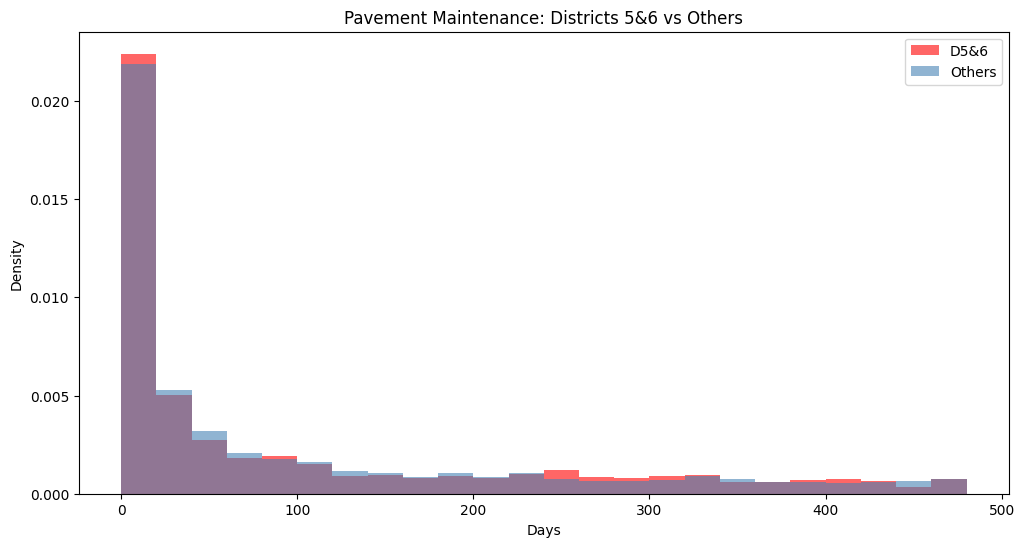

In [10]:
# Deep dive on pavement maintenance
pavement_slow = slow_districts[slow_districts['service_name'] == 'Pavement Maintenance']
pavement_fast = fast_districts[fast_districts['service_name'] == 'Pavement Maintenance']

print("=== PAVEMENT MAINTENANCE DEEP DIVE ===")
print(f"Districts 5 & 6: {pavement_slow['case_age_days'].median():.0f} days ({len(pavement_slow):,} cases)")
print(f"Other Districts: {pavement_fast['case_age_days'].median():.0f} days ({len(pavement_fast):,} cases)")
print(f"Difference: {pavement_slow['case_age_days'].median() - pavement_fast['case_age_days'].median():.0f} extra days")

# Visualize
plt.figure(figsize=(12, 6))
plt.hist(pavement_slow['case_age_days'], bins=np.arange(0, 500, 20), alpha=0.6, label='D5&6', color='red', density=True)
plt.hist(pavement_fast['case_age_days'], bins=np.arange(0, 500, 20), alpha=0.6, label='Others', color='steelblue', density=True)
plt.xlabel('Days')
plt.ylabel('Density')
plt.title('Pavement Maintenance: Districts 5&6 vs Others')
plt.legend()
plt.show()

## Top Case-Type Distribution by District

Boxplots for high-volume case types compare district medians and spread, highlighting service-specific operational gaps.

### Finding
- Illegal dumping, which is the highest volume case, seems to be signifcantly higher for districts 5 & 6, while the other council districts seem to get it resolved within the same day


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_80368/4133260144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = master_top10, kind = "box", y = "case_age_days",


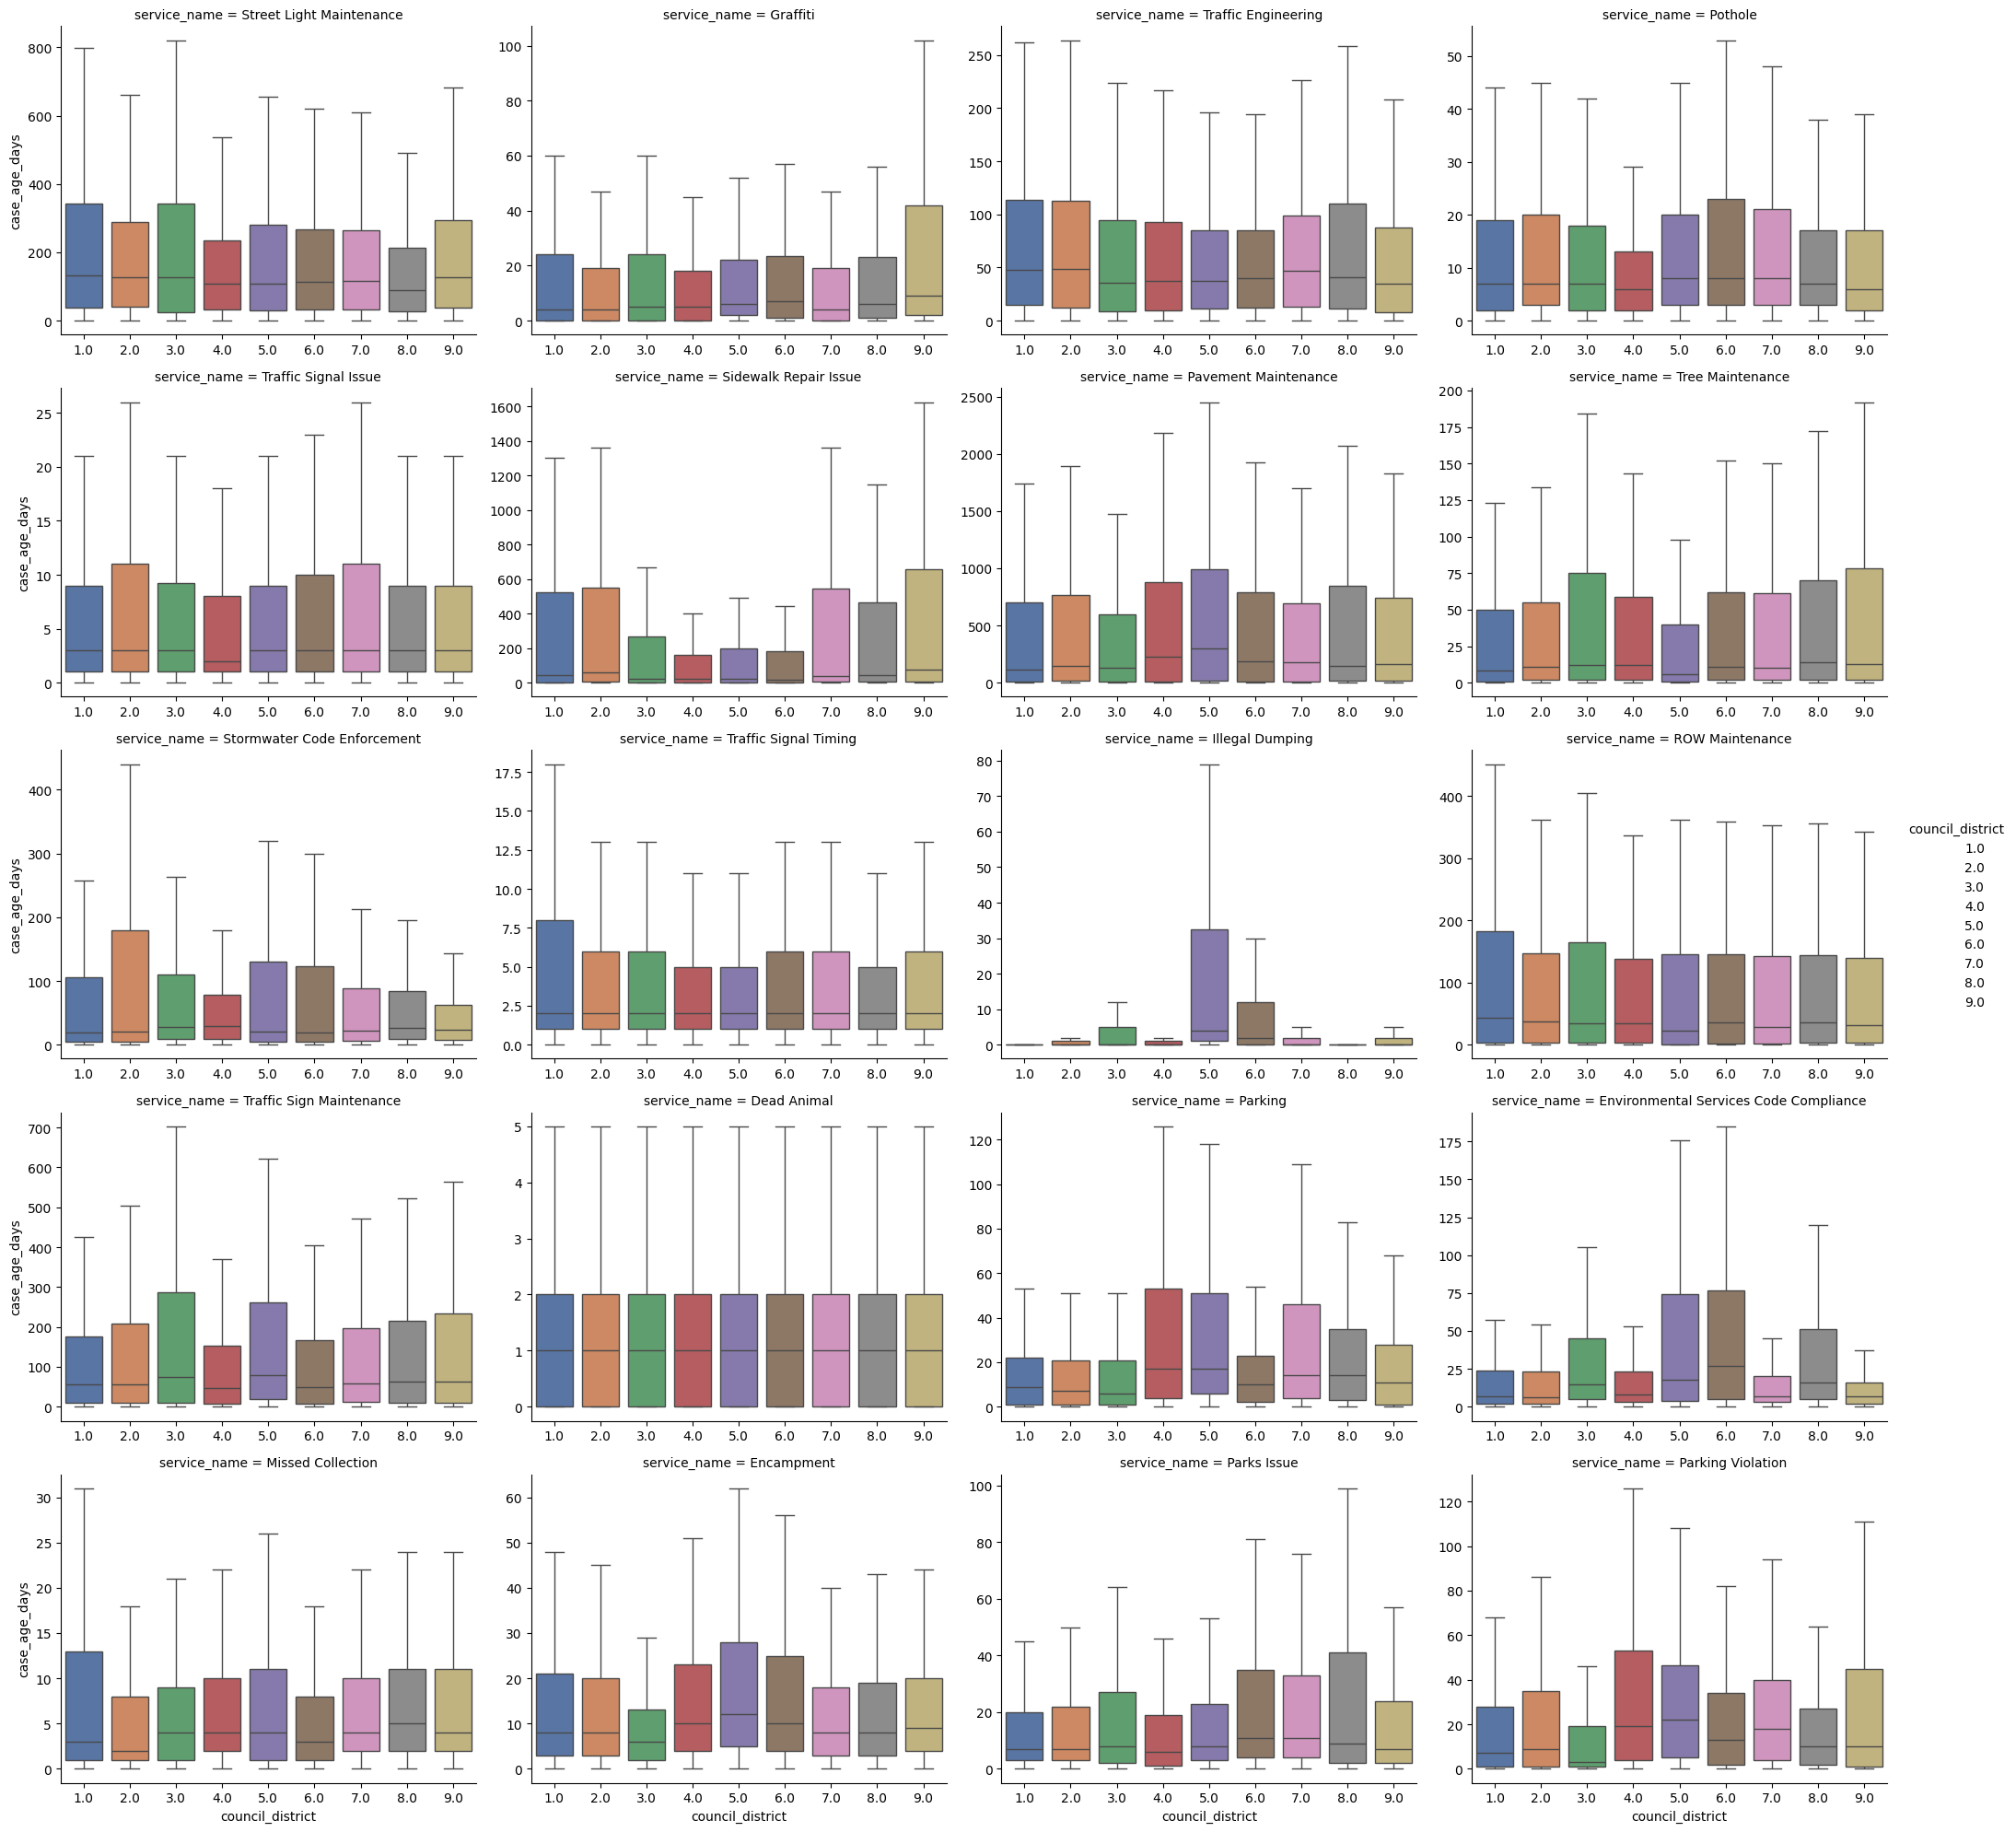

In [11]:
district_case_counts = master[["service_name", "council_district", "lat"]].groupby(["service_name", "council_district"]).count().reset_index().rename(columns={"lat": "count"})
district_counts = master.value_counts("council_district")
balanced = district_case_counts.merge(district_counts, on="council_district", suffixes=("", "_district_total"))
balanced["count"] = balanced["count"]/balanced["count_district_total"]
balanced = balanced.groupby("service_name")["count"].sum().sort_values(ascending=False).head(20)
top_10_cases = list(balanced.index)
# This finds the top 10 most common cases across the districts, and balancing each district by case_count

master_top10 = master[master["service_name"].isin(top_10_cases)]
sns.catplot(data = master_top10, kind = "box", y = "case_age_days", 
            x = "council_district", showfliers = False, palette="deep", 
            col = "service_name", col_wrap = 4, height = 4, aspect = 1.3, 
            sharey=False, sharex=False);
#sns.boxplot(y = "case_age_days", x = "council_district", data = master[master["service_name"]=="Illegal Dumping"], showfliers = False, palette="deep")

#top_10_cases

## Illegal Dumping Analysis

This section separates two concepts:
- request volume concentration, and
- delay severity by district.

The goal is to avoid conflating high volume with slow service.

- The distributions seems to be the exact same regardless if it is a fast or a slow case


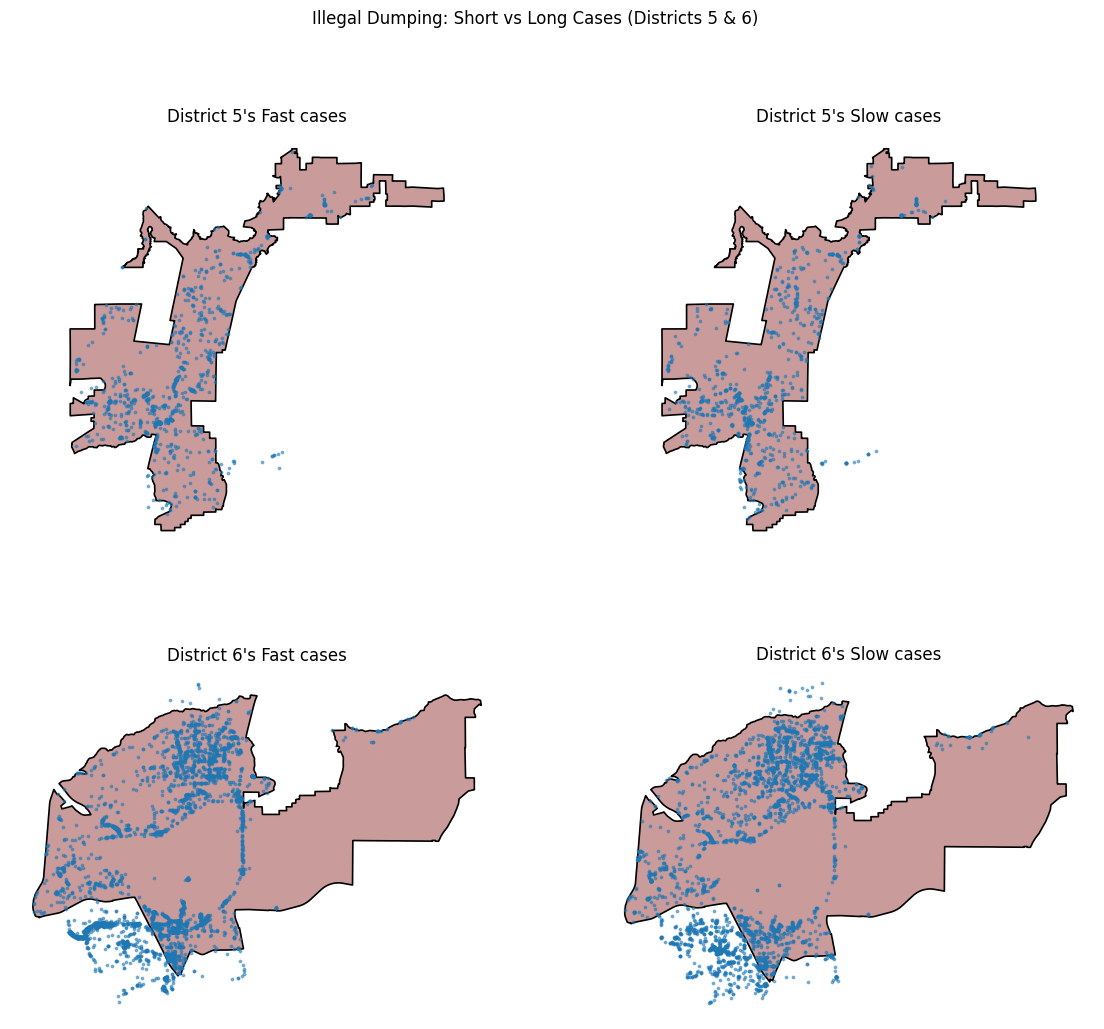


=== Illegal Dumping: Median Case Age by District ===
District 1: 0.0 days
District 2: 0.0 days
District 3: 0.0 days
District 4: 0.0 days
District 5: 4.0 days
District 6: 2.0 days
District 7: 0.0 days
District 8: 0.0 days
District 9: 0.0 days

=== Illegal Dumping: Request Volume by District ===
District 1: 24,074 requests (5.94%)
District 2: 50,702 requests (12.50%)
District 3: 58,969 requests (14.54%)
District 4: 53,144 requests (13.11%)
District 5: 1,827 requests (0.45%)
District 6: 7,646 requests (1.89%)
District 7: 18,287 requests (4.51%)
District 8: 63,034 requests (15.54%)
District 9: 127,839 requests (31.52%)

Total Illegal Dumping Requests: 419,055


In [12]:
#%pip install geopandas
import geopandas as gpd
# building district map
d_map = gpd.read_file("csv_files/council_districts_datasd.geojson").rename(columns={"district":"council_district"})
d_map56 = d_map[d_map["council_district"].isin([5, 6])].to_crs("EPSG:3857")

# building database with districts 5 and 6 with category
dumpings5 = master[(master["service_name"]=="Illegal Dumping")
                    & (master["council_district"].isin([5])) & (master["lat"].notna())                     
                    & (master["lng"].notna())][["lat", "lng", "case_age_days", "council_district"]]
dumpings6 = master[(master["service_name"]=="Illegal Dumping")                     
                   & (master["council_district"].isin([6])) & (master["lat"].notna())                     
                   & (master["lng"].notna())][["lat", "lng", "case_age_days", "council_district"]]
dumpings5["speed"] = pd.cut(dumpings5["case_age_days"], bins = [0, 4, np.inf], labels = ["Fast", "Slow"],include_lowest=True)
dumpings6["speed"] = pd.cut(dumpings6["case_age_days"], bins = [0, 2, np.inf], labels = ["Fast", "Slow"],include_lowest=True)
dumpings56 = pd.concat([dumpings5,dumpings6])
gdf = gpd.GeoDataFrame(dumpings56, geometry=gpd.points_from_xy(dumpings56["lng"], dumpings56["lat"]), 
                       crs = "EPSG:4326").to_crs("EPSG:3857")

#plotting dataframe
fix,axes = plt.subplots(2, 2, figsize = (14, 12))
for i, district_num in enumerate([5, 6]):
    for j, grp in enumerate(["Fast", "Slow"]):
        ax = axes[i, j]
        boundary = d_map56[d_map56["council_district"]==district_num]
        boundary.plot(ax=ax, color = "#c99b9b", edgecolor="black", linewidth=1.2)
        part = gdf[(gdf["council_district"] == district_num) & (gdf["speed"]==grp)]
        part.plot(ax = ax, markersize=3, alpha = 0.5)
        ax.set_title(f"District {district_num}'s {grp} cases")
        ax.set_axis_off()
plt.suptitle("Illegal Dumping: Short vs Long Cases (Districts 5 & 6)", y = 0.98)
plt.show()

# print findings nicely 
illegal = master[master["service_name"] == "Illegal Dumping"].copy()

median_by_district = (
    illegal.groupby("council_district")["case_age_days"]
    .median()
    .sort_index()
)

count_by_district = (
    illegal["council_district"]
    .value_counts()
    .sort_index()
)

pct_by_district = (count_by_district / count_by_district.sum() * 100).round(2)

print("\n=== Illegal Dumping: Median Case Age by District ===")
for d, m in median_by_district.items():
    print(f"District {int(d)}: {m:.1f} days")

print("\n=== Illegal Dumping: Request Volume by District ===")
for d, n in count_by_district.items():
    print(f"District {int(d)}: {n:,} requests ({pct_by_district.loc[d]:.2f}%)")

print(f"\nTotal Illegal Dumping Requests: {len(illegal):,}")

# find number of requests for a neighborbhood for that response that
# 

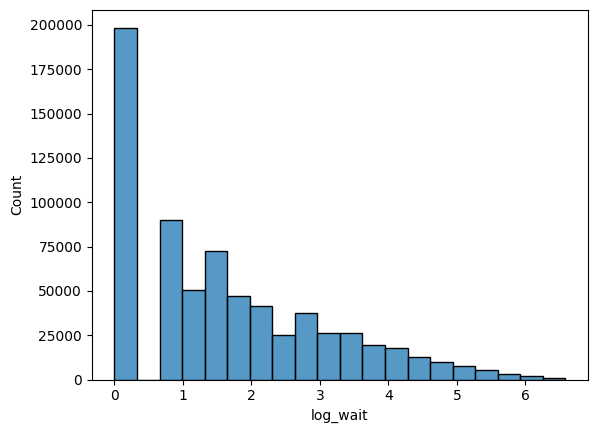

In [13]:
mixed_df = master.copy()
np.random.seed(42)
# mixed_df["year"] = mixed_df["year"].apply(int)
# mixed_df = mixed_df[mixed_df["year"]>=2024]
# cutoff = mixed_df["case_age_days"].quantile(0.99)
# print(cutoff)
# mixed_df = mixed_df[mixed_df["case_age_days"]< cutoff]


mixed_df = mixed_df[master["date_requested"].between("2024-01-01", "2025-12-31")
                    & master["date_closed"].between("2024-01-01", "2025-12-31")]
mixed_df["date_requested"] = pd.to_datetime(master["date_requested"])
mixed_df["log_wait"] = np.log1p(mixed_df["case_age_days"])
sns.histplot(mixed_df["log_wait"], bins = 20)
mixed_df["month"] = mixed_df["date_requested"].dt.to_period("M").dt.to_timestamp()
mixed_df["month_total"] = mixed_df.groupby("month")["service_name"].transform("count")
mixed_df["neigh_monthly_req"] = mixed_df.groupby(["month", "comm_plan_name"])["service_name"].transform("count")
mixed_df["neigh_share"] = mixed_df["neigh_monthly_req"]/mixed_df["month_total"]
# used as most of the time mixedlm requires a groups argument for one heierarchial grouping(like student within schools)
# butt since our data is cross classified as each case belongs to both a neighboorhod and a request type
# this will createa. workaround as the model can run the fake group and the real structure will come from vc

# originally had council_district but got a convergance warning()non positive definite hessian) so im removing it
mixed_df = mixed_df[["case_age_days", "neigh_share", "month", "council_district",
    "comm_plan_name", "service_name", "log_wait"]]
mixed_df = mixed_df.dropna()
mixed_df["one"] = 1
# 

## Mixed-Effects Modeling (Cross-Classified)

### Model Design
- Outcome: `log_wait = log1p(case_age_days)`
- Fixed effects: neighborhood share predictor and month controls
- Random effects: neighborhood (`comm_plan_name`) and request type (`service_name`)

### Documented Result
- The main specification reports a negative coefficient for neighborhood request share, indicating lower-share neighborhoods tend to have slower response times after controls.
- statistically significant model, however when checking window sensitivity, the effect doesn't appear


### Challenges Encountered
- Some sort of window size bias, as it seems like only for the full effect of the model was significant
- it is worth noting that at 90-95-99% cutoff at both neighborhood size and case type volume, it wasn't significant
- I can't tell if its because of the windows taking too much data off, or this finding isn't applicable at all



In [14]:
vc = {
    "neighborhood": "0 + C(comm_plan_name)",
    "request_type": "0 + C(service_name)"
}
# this adds a random intercept for each neighborhood and request type
# 0 says no extra intercepot here
# let baseline wait time differ by neighborhood and request type

# originally had council_district but got a convergance warning()non positive definite hessian) so im removing it
res_trim = sm.mixedlm(
    "log_wait ~ neigh_share + C(month)",
    data = mixed_df,
    groups = "one",
    re_formula="0",
    vc_formula=vc
)
result = res_trim.fit(method = "lbfgs")# gradient based otpimizer that is more stable for mlarge mixed models, regular is less stable for complex ones
result.summary()



<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                      MixedLM           Dependent Variable:          log_wait     
No. Observations:           692042            Method:                      REML         
No. Groups:                 1                 Scale:                       1.4561       
Min. group size:            692042            Log-Likelihood:              -1112329.5848
Max. group size:            692042            Converged:                   Yes          
Mean group size:            692042.0                                                    
----------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                     2.452    0.165  14.903 0.000  2.130  2.775
C(month)[T.Timestamp('2024-02-01 00:00:00')] -0.035    0.009  -3.676 0.000 -0.053 -0.016
C(month)[T.Timestamp('2024-03-01 00:00:00')] -0.066    0.009  -7.021 0.000 -0.085 -0.048
C(month)[T.Timestamp('2024-04-01 00:00:00')] -0.035    0.009  -3.723 0.000 -0.054 -0.017
C(month)[T.Timestamp('2024-05-01 00:00:00')] -0.015    0.009  -1.567 0.117 -0.033  0.004
C(month)[T.Timestamp('2024-06-01 00:00:00')]  0.165    0.010  17.027 0.000  0.146  0.184
C(month)[T.Timestamp('2024-07-01 00:00:00')]  0.083    0.009   8.891 0.000  0.064  0.101
C(month)[T.Timestamp('2024-08-01 00:00:00')]  0.079    0.009   8.491 0.000  0.061  0.098
C(month)[T.Timestamp('2024-09-01 00:00:00')] -0.020    0.010  -2.050 0.040 -0.039 -0.001
C(month)[T.Timestamp('2024-10-01 00:00:00')] -0.151    0.010 -15.702 0.000 -0.170 -0.132
C(month)[T.Timestamp('2024-11-01 00:00:00')] -0.233    0.010 -22.937 0.000 -0.253 -0.213
C(month)[T.Timestamp('2024-12-01 00:00:00')] -0.256    0.010 -24.950 0.000 -0.276 -0.236
C(month)[T.Timestamp('2025-01-01 00:00:00')] -0.264    0.010 -26.981 0.000 -0.283 -0.245
C(month)[T.Timestamp('2025-02-01 00:00:00')] -0.128    0.010 -12.713 0.000 -0.148 -0.109
C(month)[T.Timestamp('2025-03-01 00:00:00')] -0.050    0.010  -5.137 0.000 -0.069 -0.031
C(month)[T.Timestamp('2025-04-01 00:00:00')] -0.194    0.010 -19.535 0.000 -0.214 -0.175
C(month)[T.Timestamp('2025-05-01 00:00:00')] -0.212    0.010 -21.152 0.000 -0.232 -0.192
C(month)[T.Timestamp('2025-06-01 00:00:00')] -0.216    0.010 -21.608 0.000 -0.236 -0.197
C(month)[T.Timestamp('2025-07-01 00:00:00')] -0.185    0.010 -19.012 0.000 -0.204 -0.166
C(month)[T.Timestamp('2025-08-01 00:00:00')] -0.202    0.010 -20.821 0.000 -0.221 -0.183
C(month)[T.Timestamp('2025-09-01 00:00:00')] -0.346    0.010 -34.678 0.000 -0.365 -0.326
C(month)[T.Timestamp('2025-10-01 00:00:00')] -0.474    0.010 -46.830 0.000 -0.494 -0.454
C(month)[T.Timestamp('2025-11-01 00:00:00')] -0.579    0.011 -54.349 0.000 -0.600 -0.558
C(month)[T.Timestamp('2025-12-01 00:00:00')] -0.715    0.011 -65.012 0.000 -0.736 -0.693
neigh_share                                  -1.032    0.190  -5.436 0.000 -1.404 -0.660
neighborhood Var                              0.019    0.003                            
request_type Var                              1.002    0.205                            
========================================================================================

"""

## Sensitivity Test: Top 90% Category Mass

This robustness check restricts analysis to the highest-volume request and neighborhood categories to test whether core directional findings persist.


In [15]:
#making model database, cutting off top 99~ cases in casetimes

mixed_df95 = mixed_df.copy()
print(f"Original length of dataframe is {len(mixed_df95)}")
# cutoff = mixed_df95["case_age_days"].quantile(0.99)
# #print(cutoff)
# mixed_df95 = mixed_df95[mixed_df95["case_age_days"]<cutoff]
mixed_df95["neigh_c"] = mixed_df95.groupby("comm_plan_name")["comm_plan_name"].transform("count") / len(mixed_df95)
mixed_df95 = mixed_df95.sort_values("neigh_c", ascending=False)

# Making neighborhood database with only top 90%
# halved the number of neighborhoods just taking top 90
neigh95 = mixed_df95.groupby("comm_plan_name", as_index=False)["service_name"].count().sort_values('service_name', ascending=False)
neigh95['pct'] = neigh95.service_name / sum(neigh95.service_name)
neigh95['cum_pct'] = neigh95.pct.cumsum()
neigh95 = neigh95[neigh95["cum_pct"]<.9]
top_95_neigh = neigh95.comm_plan_name.tolist()
print(f"Length of top 90% neighborhoods is {len(neigh95)} originally 54")


# Making service_name database with only top 90%
dist95 = (
    mixed_df95.groupby("service_name", as_index=False)["comm_plan_name"]
    .count()
    .rename(columns={"comm_plan_name": "n"})
    .sort_values("n", ascending=False)
)
dist95["pct"] = dist95["n"] / dist95["n"].sum()
dist95["cum_pct"] = dist95["pct"].cumsum()
dist95 = dist95[dist95["cum_pct"] < 0.9]
print(f"Length of top 90% service request is {len(dist95)} originally 43")
top_95_req = dist95.service_name.tolist()



mixed_df95 = mixed_df95[(mixed_df95["service_name"].isin(top_95_req))&(mixed_df95["comm_plan_name"].isin(top_95_neigh))]
print(f"New length of dataframe is {len(mixed_df95)}")
res_trim_90 = sm.mixedlm(
    "log_wait ~ neigh_c + C(month)",
    data = mixed_df95,
    groups = "one",
    re_formula="0",
    vc_formula=vc
)
result90 = res_trim_90.fit(method = "lbfgs")
result90.summary()


Original length of dataframe is 692042
Length of top 90% neighborhoods is 27 originally 54
Length of top 90% service request is 12 originally 43
New length of dataframe is 557496


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                       MixedLM           Dependent Variable:          log_wait    
No. Observations:            557496            Method:                      REML        
No. Groups:                  1                 Scale:                       1.3376      
Min. group size:             557496            Log-Likelihood:              -872327.4188
Max. group size:             557496            Converged:                   Yes         
Mean group size:             557496.0                                                   
----------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                     1.700    0.183   9.285 0.000  1.341  2.059
C(month)[T.Timestamp('2024-02-01 00:00:00')] -0.023    0.010  -2.333 0.020 -0.043 -0.004
C(month)[T.Timestamp('2024-03-01 00:00:00')] -0.051    0.010  -5.104 0.000 -0.070 -0.031
C(month)[T.Timestamp('2024-04-01 00:00:00')] -0.000    0.010  -0.023 0.982 -0.020  0.019
C(month)[T.Timestamp('2024-05-01 00:00:00')]  0.017    0.010   1.738 0.082 -0.002  0.036
C(month)[T.Timestamp('2024-06-01 00:00:00')]  0.205    0.010  20.262 0.000  0.185  0.225
C(month)[T.Timestamp('2024-07-01 00:00:00')]  0.130    0.010  13.335 0.000  0.111  0.149
C(month)[T.Timestamp('2024-08-01 00:00:00')]  0.161    0.010  16.488 0.000  0.142  0.180
C(month)[T.Timestamp('2024-09-01 00:00:00')]  0.061    0.010   6.039 0.000  0.041  0.081
C(month)[T.Timestamp('2024-10-01 00:00:00')] -0.086    0.010  -8.453 0.000 -0.105 -0.066
C(month)[T.Timestamp('2024-11-01 00:00:00')] -0.182    0.011 -16.910 0.000 -0.203 -0.161
C(month)[T.Timestamp('2024-12-01 00:00:00')] -0.218    0.011 -20.255 0.000 -0.239 -0.197
C(month)[T.Timestamp('2025-01-01 00:00:00')] -0.208    0.010 -20.191 0.000 -0.228 -0.188
C(month)[T.Timestamp('2025-02-01 00:00:00')] -0.073    0.011  -6.891 0.000 -0.093 -0.052
C(month)[T.Timestamp('2025-03-01 00:00:00')]  0.012    0.010   1.189 0.235 -0.008  0.032
C(month)[T.Timestamp('2025-04-01 00:00:00')] -0.132    0.010 -12.782 0.000 -0.153 -0.112
C(month)[T.Timestamp('2025-05-01 00:00:00')] -0.136    0.010 -12.928 0.000 -0.156 -0.115
C(month)[T.Timestamp('2025-06-01 00:00:00')] -0.137    0.010 -13.045 0.000 -0.157 -0.116
C(month)[T.Timestamp('2025-07-01 00:00:00')] -0.097    0.010  -9.604 0.000 -0.117 -0.078
C(month)[T.Timestamp('2025-08-01 00:00:00')] -0.140    0.010 -13.849 0.000 -0.160 -0.120
C(month)[T.Timestamp('2025-09-01 00:00:00')] -0.273    0.010 -26.046 0.000 -0.293 -0.252
C(month)[T.Timestamp('2025-10-01 00:00:00')] -0.391    0.011 -36.161 0.000 -0.412 -0.370
C(month)[T.Timestamp('2025-11-01 00:00:00')] -0.423    0.012 -36.724 0.000 -0.446 -0.401
C(month)[T.Timestamp('2025-12-01 00:00:00')] -0.504    0.012 -42.918 0.000 -0.527 -0.481
neigh_c                                      -1.554    1.208  -1.286 0.198 -3.922  0.814
neighborhood Var                              0.022    0.005                            
request_type Var                              0.372    0.135                            
========================================================================================

"""

## Sensitivity Test: Top 95% Category Mass

This robustness check expands category coverage relative to the 90% scenario to evaluate effect stability under broader inclusion.


In [16]:
#making model database, cutting off top 99~ cases in casetimes

mixed_df95 = mixed_df.copy()
print(f"Original length of dataframe is {len(mixed_df95)}")
# cutoff = mixed_df95["case_age_days"].quantile(0.99)
# #print(cutoff)
# mixed_df95 = mixed_df95[mixed_df95["case_age_days"]<cutoff]
mixed_df95["neigh_c"] = mixed_df95.groupby("comm_plan_name")["comm_plan_name"].transform("count") / len(mixed_df95)
mixed_df95 = mixed_df95.sort_values("neigh_c", ascending=False)

# Making neighborhood database with only top 95%

neigh95 = mixed_df95.groupby("comm_plan_name", as_index=False)["service_name"].count().sort_values('service_name', ascending=False)
neigh95['pct'] = neigh95.service_name / sum(neigh95.service_name)
neigh95['cum_pct'] = neigh95.pct.cumsum()
neigh95 = neigh95[neigh95["cum_pct"]<.95]
top_95_neigh = neigh95.comm_plan_name.tolist()
print(f"Length of top 95% neighborhoods is {len(neigh95)} originally 54")


# Making service_name database with only top 95%
dist95 = (
    mixed_df95.groupby("service_name", as_index=False)["comm_plan_name"]
    .count()
    .rename(columns={"comm_plan_name": "n"})
    .sort_values("n", ascending=False)
)
dist95["pct"] = dist95["n"] / dist95["n"].sum()
dist95["cum_pct"] = dist95["pct"].cumsum()
dist95 = dist95[dist95["cum_pct"] < 0.95]
print(f"Length of top 95% service request is {len(dist95)} originally 43")
top_95_req = dist95.service_name.tolist()



mixed_df95 = mixed_df95[(mixed_df95["service_name"].isin(top_95_req))&(mixed_df95["comm_plan_name"].isin(top_95_neigh))]
print(f"New length of dataframe is {len(mixed_df95)}")
res_trim_90 = sm.mixedlm(
    "log_wait ~ neigh_c + C(month)",
    data = mixed_df95,
    groups = "one",
    re_formula="0",
    vc_formula=vc
)
result90 = res_trim_90.fit(method = "lbfgs")
result90.summary()


Original length of dataframe is 692042
Length of top 95% neighborhoods is 32 originally 54
Length of top 95% service request is 18 originally 43
New length of dataframe is 622790


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                       MixedLM           Dependent Variable:          log_wait    
No. Observations:            622790            Method:                      REML        
No. Groups:                  1                 Scale:                       1.4104      
Min. group size:             622790            Log-Likelihood:              -991025.4155
Max. group size:             622790            Converged:                   Yes         
Mean group size:             622790.0                                                   
----------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                     2.311    0.254   9.100 0.000  1.813  2.808
C(month)[T.Timestamp('2024-02-01 00:00:00')] -0.031    0.010  -3.211 0.001 -0.050 -0.012
C(month)[T.Timestamp('2024-03-01 00:00:00')] -0.056    0.010  -5.803 0.000 -0.075 -0.037
C(month)[T.Timestamp('2024-04-01 00:00:00')] -0.013    0.010  -1.313 0.189 -0.032  0.006
C(month)[T.Timestamp('2024-05-01 00:00:00')]  0.011    0.010   1.130 0.258 -0.008  0.030
C(month)[T.Timestamp('2024-06-01 00:00:00')]  0.190    0.010  19.289 0.000  0.171  0.210
C(month)[T.Timestamp('2024-07-01 00:00:00')]  0.108    0.009  11.383 0.000  0.089  0.126
C(month)[T.Timestamp('2024-08-01 00:00:00')]  0.119    0.010  12.488 0.000  0.100  0.138
C(month)[T.Timestamp('2024-09-01 00:00:00')]  0.019    0.010   1.952 0.051 -0.000  0.038
C(month)[T.Timestamp('2024-10-01 00:00:00')] -0.122    0.010 -12.417 0.000 -0.142 -0.103
C(month)[T.Timestamp('2024-11-01 00:00:00')] -0.213    0.010 -20.424 0.000 -0.233 -0.193
C(month)[T.Timestamp('2024-12-01 00:00:00')] -0.236    0.010 -22.570 0.000 -0.256 -0.215
C(month)[T.Timestamp('2025-01-01 00:00:00')] -0.238    0.010 -23.831 0.000 -0.258 -0.218
C(month)[T.Timestamp('2025-02-01 00:00:00')] -0.094    0.010  -9.125 0.000 -0.114 -0.074
C(month)[T.Timestamp('2025-03-01 00:00:00')] -0.012    0.010  -1.204 0.228 -0.031  0.008
C(month)[T.Timestamp('2025-04-01 00:00:00')] -0.155    0.010 -15.284 0.000 -0.175 -0.135
C(month)[T.Timestamp('2025-05-01 00:00:00')] -0.169    0.010 -16.492 0.000 -0.189 -0.149
C(month)[T.Timestamp('2025-06-01 00:00:00')] -0.176    0.010 -17.173 0.000 -0.196 -0.156
C(month)[T.Timestamp('2025-07-01 00:00:00')] -0.135    0.010 -13.610 0.000 -0.154 -0.115
C(month)[T.Timestamp('2025-08-01 00:00:00')] -0.162    0.010 -16.413 0.000 -0.181 -0.143
C(month)[T.Timestamp('2025-09-01 00:00:00')] -0.298    0.010 -29.356 0.000 -0.318 -0.278
C(month)[T.Timestamp('2025-10-01 00:00:00')] -0.417    0.010 -40.063 0.000 -0.437 -0.397
C(month)[T.Timestamp('2025-11-01 00:00:00')] -0.553    0.011 -50.307 0.000 -0.574 -0.531
C(month)[T.Timestamp('2025-12-01 00:00:00')] -0.644    0.011 -56.763 0.000 -0.666 -0.621
neigh_c                                      -1.496    1.033  -1.448 0.148 -3.521  0.529
neighborhood Var                              0.019    0.004                            
request_type Var                              1.132    0.332                            
========================================================================================

"""

## Sensitivity Test: Top 99% Category Mass

This near-full-coverage test checks whether conclusions remain directionally stable when retaining almost all category mass.


In [17]:
#making model database, cutting off top 99~ cases in casetimes

mixed_df95 = mixed_df.copy()
print(f"Original length of dataframe is {len(mixed_df95)}")
# cutoff = mixed_df95["case_age_days"].quantile(0.99)
# #print(cutoff)
# mixed_df95 = mixed_df95[mixed_df95["case_age_days"]<cutoff]
mixed_df95["neigh_c"] = mixed_df95.groupby("comm_plan_name")["comm_plan_name"].transform("count") / len(mixed_df95)
mixed_df95 = mixed_df95.sort_values("neigh_c", ascending=False)

# Making neighborhood database with only top 95%

neigh95 = mixed_df95.groupby("comm_plan_name", as_index=False)["service_name"].count().sort_values('service_name', ascending=False)
neigh95['pct'] = neigh95.service_name / sum(neigh95.service_name)
neigh95['cum_pct'] = neigh95.pct.cumsum()
neigh95 = neigh95[neigh95["cum_pct"]<.99]
top_95_neigh = neigh95.comm_plan_name.tolist()
print(f"Length of top 95% neighborhoods is {len(neigh95)} originally 54")


# Making service_name database with only top 95%
dist95 = (
    mixed_df95.groupby("service_name", as_index=False)["comm_plan_name"]
    .count()
    .rename(columns={"comm_plan_name": "n"})
    .sort_values("n", ascending=False)
)
dist95["pct"] = dist95["n"] / dist95["n"].sum()
dist95["cum_pct"] = dist95["pct"].cumsum()
dist95 = dist95[dist95["cum_pct"] < 0.99]
print(f"Length of top 95% service request is {len(dist95)} originally 43")
top_95_req = dist95.service_name.tolist()



mixed_df95 = mixed_df95[(mixed_df95["service_name"].isin(top_95_req))&(mixed_df95["comm_plan_name"].isin(top_95_neigh))]
print(f"New length of dataframe is {len(mixed_df95)}")
res_trim_90 = sm.mixedlm(
    "log_wait ~ neigh_c + C(month)",
    data = mixed_df95,
    groups = "one",
    re_formula="0",
    vc_formula=vc
)
result90 = res_trim_90.fit(method = "lbfgs")
result90.summary()


Original length of dataframe is 692042
Length of top 95% neighborhoods is 41 originally 54
Length of top 95% service request is 25 originally 43
New length of dataframe is 675454


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                      MixedLM           Dependent Variable:          log_wait     
No. Observations:           675454            Method:                      REML         
No. Groups:                 1                 Scale:                       1.4394       
Min. group size:            675454            Log-Likelihood:              -1081718.8720
Max. group size:            675454            Converged:                   Yes          
Mean group size:            675454.0                                                    
----------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                     2.436    0.198  12.301 0.000  2.048  2.824
C(month)[T.Timestamp('2024-02-01 00:00:00')] -0.022    0.009  -2.303 0.021 -0.040 -0.003
C(month)[T.Timestamp('2024-03-01 00:00:00')] -0.052    0.009  -5.486 0.000 -0.070 -0.033
C(month)[T.Timestamp('2024-04-01 00:00:00')] -0.017    0.009  -1.850 0.064 -0.036  0.001
C(month)[T.Timestamp('2024-05-01 00:00:00')] -0.003    0.009  -0.316 0.752 -0.021  0.015
C(month)[T.Timestamp('2024-06-01 00:00:00')]  0.182    0.010  19.016 0.000  0.164  0.201
C(month)[T.Timestamp('2024-07-01 00:00:00')]  0.099    0.009  10.784 0.000  0.081  0.118
C(month)[T.Timestamp('2024-08-01 00:00:00')]  0.101    0.009  10.952 0.000  0.083  0.120
C(month)[T.Timestamp('2024-09-01 00:00:00')] -0.002    0.010  -0.239 0.811 -0.021  0.016
C(month)[T.Timestamp('2024-10-01 00:00:00')] -0.134    0.010 -13.959 0.000 -0.153 -0.115
C(month)[T.Timestamp('2024-11-01 00:00:00')] -0.217    0.010 -21.405 0.000 -0.237 -0.197
C(month)[T.Timestamp('2024-12-01 00:00:00')] -0.239    0.010 -23.486 0.000 -0.259 -0.219
C(month)[T.Timestamp('2025-01-01 00:00:00')] -0.244    0.010 -25.080 0.000 -0.263 -0.224
C(month)[T.Timestamp('2025-02-01 00:00:00')] -0.107    0.010 -10.689 0.000 -0.127 -0.087
C(month)[T.Timestamp('2025-03-01 00:00:00')] -0.032    0.010  -3.269 0.001 -0.051 -0.013
C(month)[T.Timestamp('2025-04-01 00:00:00')] -0.173    0.010 -17.501 0.000 -0.192 -0.153
C(month)[T.Timestamp('2025-05-01 00:00:00')] -0.191    0.010 -19.187 0.000 -0.210 -0.171
C(month)[T.Timestamp('2025-06-01 00:00:00')] -0.192    0.010 -19.339 0.000 -0.212 -0.173
C(month)[T.Timestamp('2025-07-01 00:00:00')] -0.157    0.010 -16.319 0.000 -0.176 -0.138
C(month)[T.Timestamp('2025-08-01 00:00:00')] -0.178    0.010 -18.587 0.000 -0.197 -0.160
C(month)[T.Timestamp('2025-09-01 00:00:00')] -0.321    0.010 -32.443 0.000 -0.340 -0.301
C(month)[T.Timestamp('2025-10-01 00:00:00')] -0.447    0.010 -44.494 0.000 -0.467 -0.427
C(month)[T.Timestamp('2025-11-01 00:00:00')] -0.552    0.011 -52.280 0.000 -0.573 -0.531
C(month)[T.Timestamp('2025-12-01 00:00:00')] -0.684    0.011 -62.365 0.000 -0.706 -0.663
neigh_c                                      -1.236    0.945  -1.308 0.191 -3.089  0.617
neighborhood Var                              0.019    0.004                            
request_type Var                              0.954    0.229                            
========================================================================================

"""

## Notebook Summary

District-level gaps are partly explained by service composition, with specific service lines showing larger inequity signals.
Mixed-effects modeling provides structural evidence that neighborhood request share is associated with response time after controls.
